In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("All libraries loaded successfully! ✅")

TensorFlow: 2.20.0
NumPy: 2.0.2
All libraries loaded successfully! ✅


In [3]:
# Load MNIST Dataset
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Training labels: (60000,)
Testing labels: (10000,)


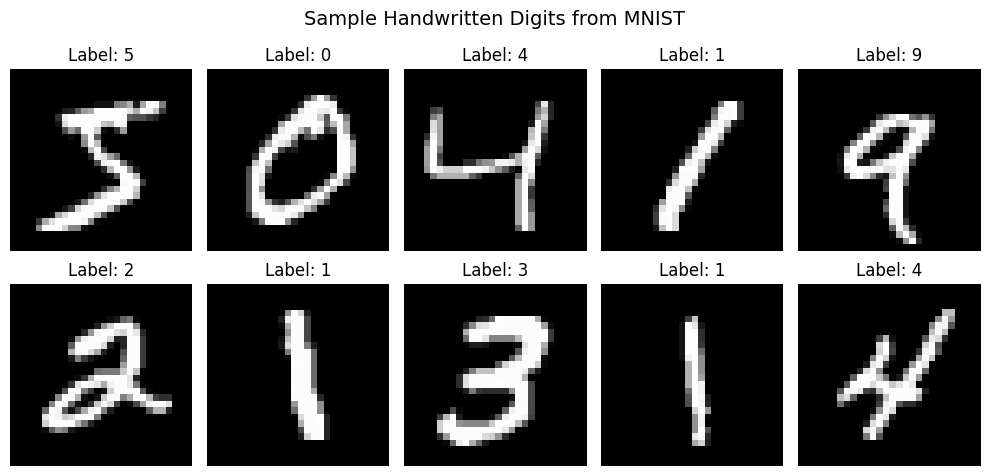

In [4]:
# Visualize sample images from dataset
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Sample Handwritten Digits from MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Preprocess the data
# Reshape: add channel dimension (28,28) -> (28,28,1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Normalize: pixel values 0-255 -> 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())
print("Preprocessing done! ✅")

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Min pixel value: 0.0
Max pixel value: 1.0
Preprocessing done! ✅


In [6]:
from tensorflow.keras import layers, models

# Build CNN Model
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    # Second Convolutional Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten & Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\nTraining Complete! ✅")


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.9476 - loss: 0.1715 - val_accuracy: 0.9845 - val_loss: 0.0523
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9820 - loss: 0.0587 - val_accuracy: 0.9887 - val_loss: 0.0348
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9873 - loss: 0.0408 - val_accuracy: 0.9913 - val_loss: 0.0322
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.9893 - loss: 0.0337 - val_accuracy: 0.9912 - val_loss: 0.0288
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.9914 - loss: 0.0260 - val_accuracy: 0.9930 - val_loss: 0.0311
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.9934 - loss: 0.0213 - val_accuracy: 0.9927 - val_loss: 0.0308
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9941 - loss: 0.0183 - val_accuracy: 0.9925 - val_loss: 0.0286
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.9947 -

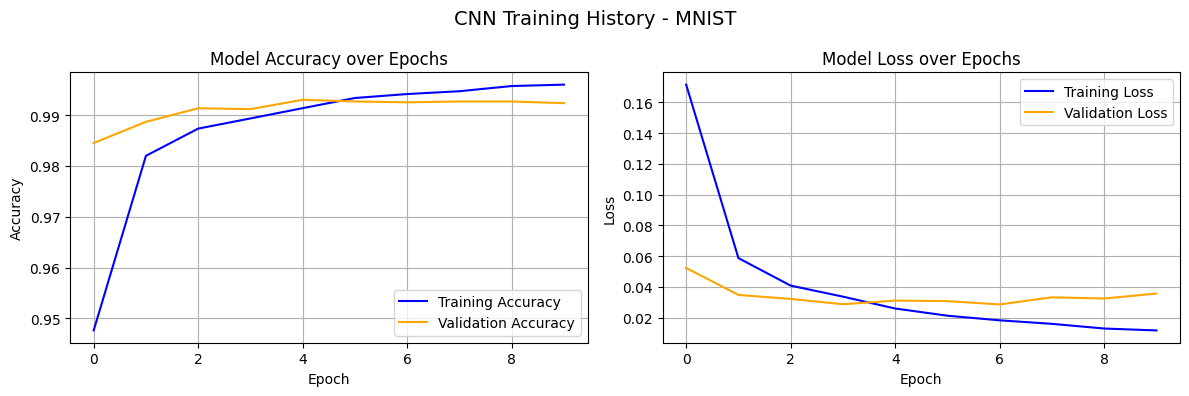

In [8]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN Training History - MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Test Loss:      {test_loss:.4f}")

Test Accuracy:  99.23%
Test Loss:      0.0252


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


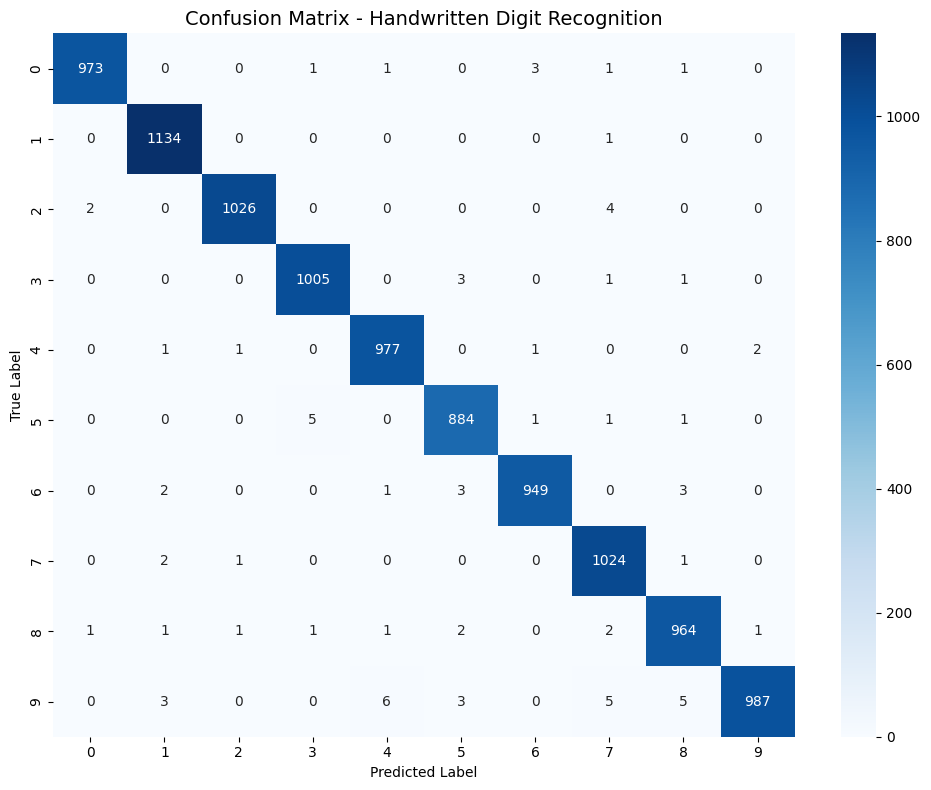

In [10]:
# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.title('Confusion Matrix - Handwritten Digit Recognition', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [11]:
# Classification Report
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_classes,
                            target_names=[f'Digit {i}' for i in range(10)]))

Classification Report
              precision    recall  f1-score   support

     Digit 0       1.00      0.99      0.99       980
     Digit 1       0.99      1.00      1.00      1135
     Digit 2       1.00      0.99      1.00      1032
     Digit 3       0.99      1.00      0.99      1010
     Digit 4       0.99      0.99      0.99       982
     Digit 5       0.99      0.99      0.99       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       0.99      1.00      0.99      1028
     Digit 8       0.99      0.99      0.99       974
     Digit 9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



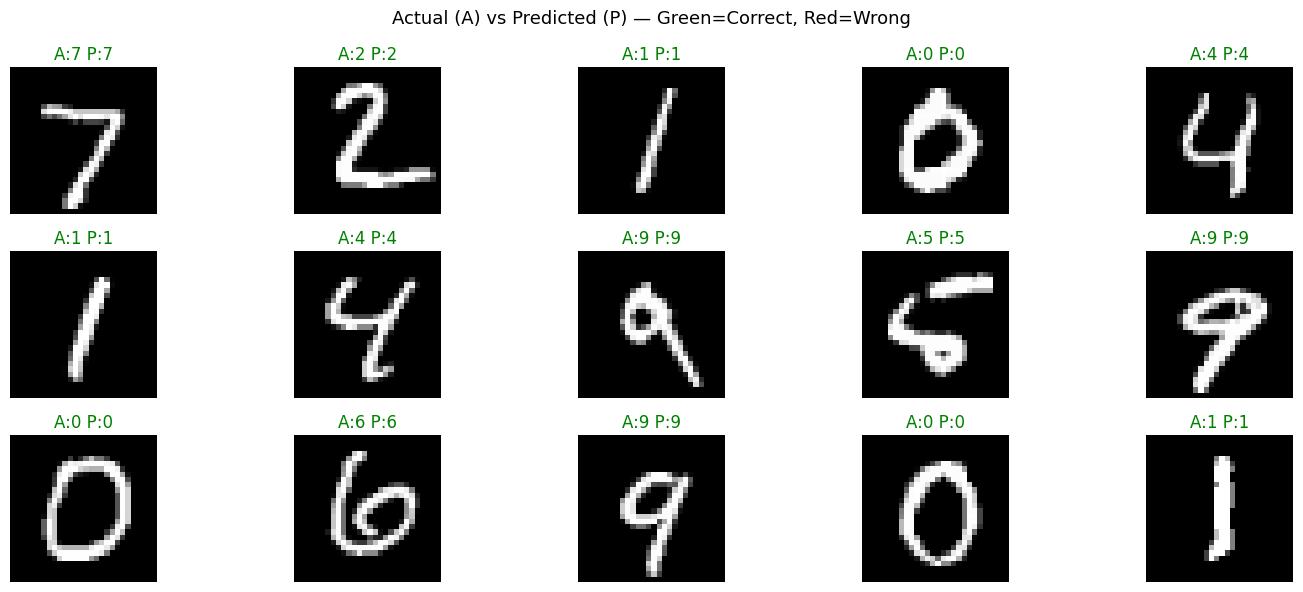

In [12]:
# Visualize sample predictions
plt.figure(figsize=(15, 6))

for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    actual = y_test[i]
    predicted = y_pred_classes[i]

    color = 'green' if actual == predicted else 'red'
    plt.title(f'A:{actual} P:{predicted}', color=color)
    plt.axis('off')

plt.suptitle('Actual (A) vs Predicted (P) — Green=Correct, Red=Wrong', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
import ipywidgets as widgets
from IPython.display import display, HTML
from PIL import Image
import numpy as np
import io
import base64

def predict_from_canvas(image_data):
    image_data_clean = image_data.split(',')[1]
    image_bytes = base64.b64decode(image_data_clean)
    img = Image.open(io.BytesIO(image_bytes)).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)
    prediction = model.predict(img_array, verbose=0)
    digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    return int(digit), float(confidence)

canvas_html = """
<div style="text-align:center; font-family:Arial;">
  <h2>✏️ Handwritten Digit Recognizer</h2>
  <canvas id="canvas" width="280" height="280"
    style="border:4px solid #333; cursor:crosshair; background:black; border-radius:10px;">
  </canvas>
  <br><br>
  <button onclick="clearCanvas()"
    style="padding:10px 25px; margin:5px; font-size:16px; border-radius:8px; cursor:pointer;">
    🗑️ Clear
  </button>
  <button onclick="predictDigit()"
    style="padding:10px 25px; margin:5px; font-size:16px; background:#28a745;
           color:white; border:none; border-radius:8px; cursor:pointer;">
    🔍 Predict
  </button>
  <br><br>
  <div id="result"
    style="font-size:24px; font-weight:bold; color:#333; padding:15px;
           background:#f0f0f0; border-radius:10px; display:inline-block; min-width:300px;">
    Draw a digit and click Predict!
  </div>
</div>

<script>
  const canvas = document.getElementById('canvas');
  const ctx = canvas.getContext('2d');
  let drawing = false;

  ctx.fillStyle = 'black';
  ctx.fillRect(0, 0, 280, 280);
  ctx.strokeStyle = 'white';
  ctx.lineWidth = 18;
  ctx.lineCap = 'round';
  ctx.lineJoin = 'round';

  canvas.addEventListener('mousedown', (e) => { drawing = true; ctx.beginPath(); });
  canvas.addEventListener('mouseup', () => { drawing = false; ctx.beginPath(); });
  canvas.addEventListener('mouseout', () => { drawing = false; ctx.beginPath(); });
  canvas.addEventListener('mousemove', draw);

  canvas.addEventListener('touchstart', (e) => {
    drawing = true;
    ctx.beginPath();
    e.preventDefault();
  });
  canvas.addEventListener('touchend', () => { drawing = false; ctx.beginPath(); });
  canvas.addEventListener('touchmove', (e) => {
    e.preventDefault();
    const touch = e.touches[0];
    const rect = canvas.getBoundingClientRect();
    const scaleX = canvas.width / rect.width;
    const scaleY = canvas.height / rect.height;
    const x = (touch.clientX - rect.left) * scaleX;
    const y = (touch.clientY - rect.top) * scaleY;
    if (!drawing) return;
    ctx.lineTo(x, y);
    ctx.stroke();
    ctx.beginPath();
    ctx.moveTo(x, y);
  });

  function draw(e) {
    if (!drawing) return;
    const rect = canvas.getBoundingClientRect();
    const scaleX = canvas.width / rect.width;
    const scaleY = canvas.height / rect.height;
    const x = (e.clientX - rect.left) * scaleX;
    const y = (e.clientY - rect.top) * scaleY;
    ctx.lineTo(x, y);
    ctx.stroke();
    ctx.beginPath();
    ctx.moveTo(x, y);
  }

  function clearCanvas() {
    ctx.fillStyle = 'black';
    ctx.fillRect(0, 0, 280, 280);
    ctx.beginPath();
    document.getElementById('result').innerHTML = 'Draw a digit and click Predict!';
    document.getElementById('result').style.color = '#333';
  }

  function predictDigit() {
    document.getElementById('result').innerHTML = '🔄 Predicting...';
    const imageData = canvas.toDataURL('image/png');
    google.colab.kernel.invokeFunction('predict', [imageData], {})
      .then(result => {
        const output = result.data['application/json'];
        const digit = output.digit;
        const confidence = output.confidence.toFixed(2);
        document.getElementById('result').innerHTML =
          '🎯 Predicted: <span style="color:#28a745; font-size:32px;">' + digit +
          '</span> &nbsp;|&nbsp; Confidence: <span style="color:#007bff;">' +
          confidence + '%</span>';
      });
  }
</script>
"""

import google.colab.output
google.colab.output.register_callback('predict', predict_from_canvas)

display(HTML(canvas_html))